# Titanic 생존자 예측 ML
타이타닉 데이터셋을 활용한 생존자 예측 머신러닝 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# 한글 폰트 설정
font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
BASE = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\12_Titanic_ML'
DATA_PATH = BASE + r'\resources\titanic.csv'
OUTPUT_PATH = BASE + r'\output'

## 1. 데이터 살펴보기

In [2]:
df = pd.read_csv(DATA_PATH)
print('데이터 형태:', df.shape)
df.head()

데이터 형태: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 기본 정보 및 결측값 확인
print('=== 컬럼 정보 ===')
df.info()
print('\n=== 결측값 현황 ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print('\n=== 기술 통계 ===')
df.describe()

=== 컬럼 정보 ===


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

=== 결측값 현황 ===
Age         177
Cabin       687
Embarked      2
dtype: int64

=== 기술 통계 ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# 생존자 분포 확인
print('생존자 분포:')
print(df['Survived'].value_counts())
print(f"생존율: {df['Survived'].mean():.2%}")

생존자 분포:
Survived
0    549
1    342
Name: count, dtype: int64
생존율: 38.38%


## 2. 데이터 전처리

In [5]:
# 원본 복사 후 전처리 시작
df_clean = df.copy()

# Age: 중앙값으로 결측값 채우기
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Embarked: 최빈값으로 결측값 채우기
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin: 결측 비율이 높아 드롭
df_clean.drop(columns=['Cabin'], inplace=True)

# 불필요 컬럼 제거 (예측에 직접적으로 도움이 안 되는 식별자)
df_clean.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# 범주형 변수 인코딩
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex'])           # male=1, female=0
df_clean['Embarked'] = le.fit_transform(df_clean['Embarked']) # C=0, Q=1, S=2

print('전처리 완료. 결측값 확인:')
print(df_clean.isnull().sum())
print('\n최종 데이터 형태:', df_clean.shape)
df_clean.head()

전처리 완료. 결측값 확인:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

최종 데이터 형태: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## 3. EDA (탐색적 데이터 분석)

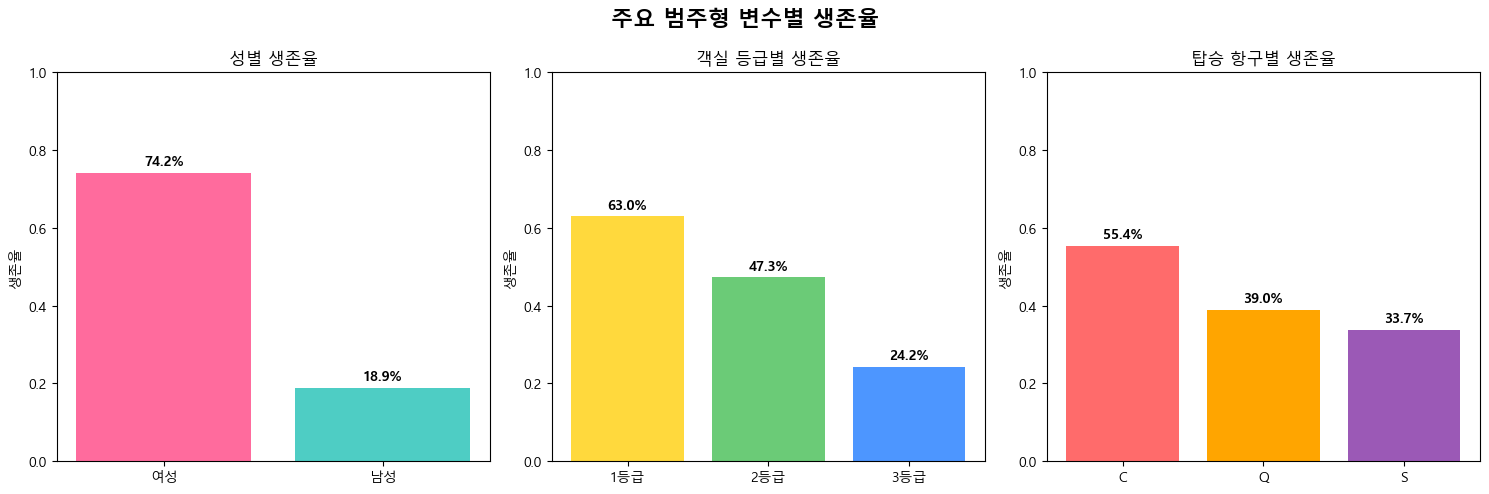

차트 1 저장 완료


In [6]:
# 차트 1: 주요 범주형 변수별 생존율
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('주요 범주형 변수별 생존율', fontsize=16, fontweight='bold')

sex_survival = df.groupby('Sex')['Survived'].mean()
axes[0].bar(['여성', '남성'], [sex_survival.get('female', 0), sex_survival.get('male', 0)],
            color=['#FF6B9D', '#4ECDC4'])
axes[0].set_title('성별 생존율')
axes[0].set_ylabel('생존율')
axes[0].set_ylim(0, 1)
for i, v in enumerate([sex_survival.get('female', 0), sex_survival.get('male', 0)]):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

pclass_survival = df.groupby('Pclass')['Survived'].mean()
axes[1].bar([f'{i}등급' for i in pclass_survival.index], pclass_survival.values,
            color=['#FFD93D', '#6BCB77', '#4D96FF'])
axes[1].set_title('객실 등급별 생존율')
axes[1].set_ylabel('생존율')
axes[1].set_ylim(0, 1)
for i, v in enumerate(pclass_survival.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

embarked_survival = df.groupby('Embarked')['Survived'].mean()
axes[2].bar(embarked_survival.index, embarked_survival.values,
            color=['#FF6B6B', '#FFA500', '#9B59B6'])
axes[2].set_title('탑승 항구별 생존율')
axes[2].set_ylabel('생존율')
axes[2].set_ylim(0, 1)
for i, v in enumerate(embarked_survival.values):
    axes[2].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + r'\01_categorical_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print('차트 1 저장 완료')

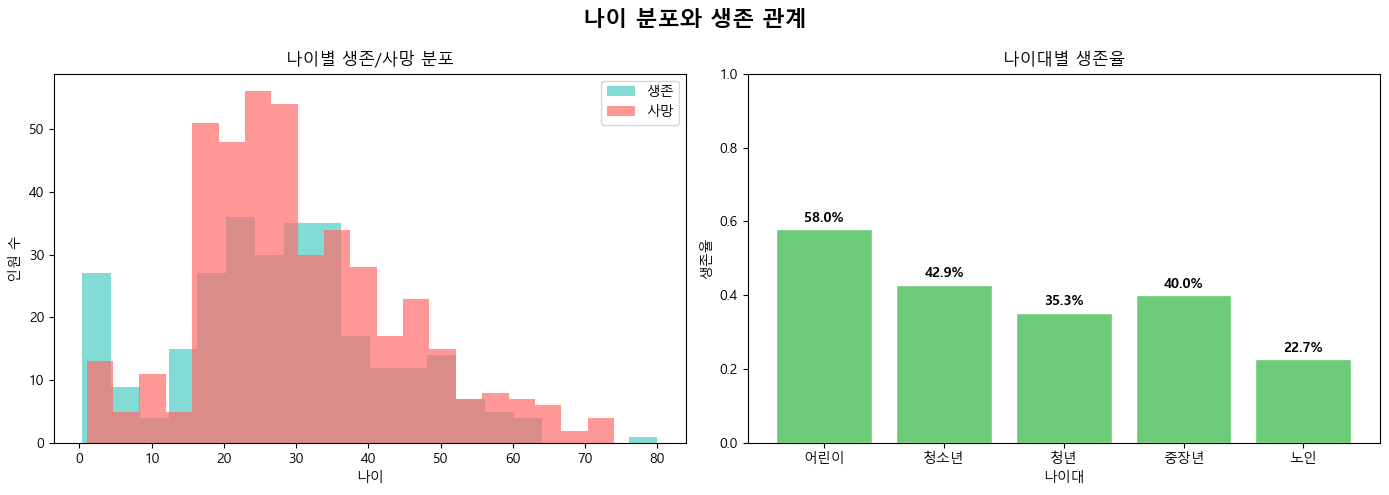

차트 2 저장 완료


In [7]:
# 차트 2: 나이 분포 및 생존 여부
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('나이 분포와 생존 관계', fontsize=16, fontweight='bold')

axes[0].hist(df[df['Survived'] == 1]['Age'].dropna(), bins=20, alpha=0.7, label='생존', color='#4ECDC4')
axes[0].hist(df[df['Survived'] == 0]['Age'].dropna(), bins=20, alpha=0.7, label='사망', color='#FF6B6B')
axes[0].set_title('나이별 생존/사망 분포')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('인원 수')
axes[0].legend()

df_age = df.copy()
df_age['Age'] = df_age['Age'].fillna(df_age['Age'].median())
df_age['AgeGroup'] = pd.cut(df_age['Age'], bins=[0, 12, 18, 35, 60, 100],
                             labels=['어린이', '청소년', '청년', '중장년', '노인'])
age_survival = df_age.groupby('AgeGroup', observed=True)['Survived'].mean()
axes[1].bar(age_survival.index, age_survival.values, color='#6BCB77', edgecolor='white')
axes[1].set_title('나이대별 생존율')
axes[1].set_xlabel('나이대')
axes[1].set_ylabel('생존율')
axes[1].set_ylim(0, 1)
for i, v in enumerate(age_survival.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + r'\02_age_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print('차트 2 저장 완료')

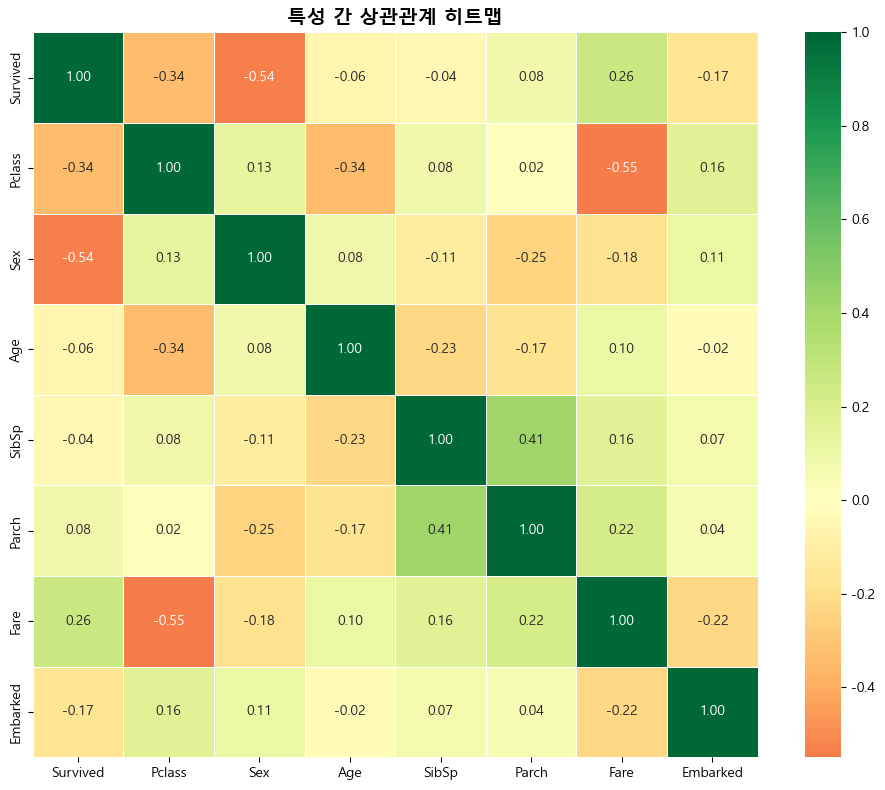

차트 3 저장 완료


In [8]:
# 차트 3: 특성 간 상관관계 히트맵
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('특성 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + r'\03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('차트 3 저장 완료')

## 4. 모델 만들기 - 가설 설정

**가설:**
- H1: 여성이 남성보다 생존율이 높다 (여성 우선 구조 원칙)
- H2: 1등급 승객이 3등급보다 생존율이 높다 (경제적 계층)
- H3: 어린이(12세 이하)가 성인보다 생존율이 높다 (어린이 우선 구조)

In [9]:
# 가설 검증
print('=== 가설 검증 ===')
sex_survival = df.groupby('Sex')['Survived'].mean()
print(f"H1 - 성별 생존율: 여성={sex_survival.get('female',0):.1%}, 남성={sex_survival.get('male',0):.1%}")
print(f"  → {'가설 채택' if sex_survival.get('female',0) > sex_survival.get('male',0) else '가설 기각'}")

pclass_survival = df.groupby('Pclass')['Survived'].mean()
print(f"\nH2 - 등급별 생존율: 1등급={pclass_survival.get(1,0):.1%}, 3등급={pclass_survival.get(3,0):.1%}")
print(f"  → {'가설 채택' if pclass_survival.get(1,0) > pclass_survival.get(3,0) else '가설 기각'}")

df_h3 = df.copy()
df_h3['Age'] = df_h3['Age'].fillna(df_h3['Age'].median())
child_survival = df_h3[df_h3['Age'] <= 12]['Survived'].mean()
adult_survival = df_h3[df_h3['Age'] > 12]['Survived'].mean()
print(f"\nH3 - 어린이/성인 생존율: 어린이={child_survival:.1%}, 성인={adult_survival:.1%}")
print(f"  → {'가설 채택' if child_survival > adult_survival else '가설 기각'}")

=== 가설 검증 ===
H1 - 성별 생존율: 여성=74.2%, 남성=18.9%
  → 가설 채택

H2 - 등급별 생존율: 1등급=63.0%, 3등급=24.2%
  → 가설 채택

H3 - 어린이/성인 생존율: 어린이=58.0%, 성인=36.7%
  → 가설 채택


## 5. 모델 학습 및 검증/예측/평가
결정트리 / 랜덤포레스트 / 로지스틱 회귀 / **XGBoost** 4개 모델 비교

In [10]:
# 특성(X)과 타깃(y) 분리
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# 학습/테스트 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}')

학습 데이터: (712, 7), 테스트 데이터: (179, 7)


In [11]:
# 4개 모델 초기화 (XGBoost 포함)
models = {
    '결정트리':    DecisionTreeClassifier(random_state=42),
    '랜덤포레스트': RandomForestClassifier(n_estimators=100, random_state=42),
    '로지스틱 회귀': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost':    XGBClassifier(n_estimators=100, learning_rate=0.1,
                                random_state=42, eval_metric='logloss', verbosity=0)
}

# K-Fold 교차검증 설정 (5겹, 층화)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    # cross_val_score()로 K-Fold 교차검증
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')

    # 전체 학습 데이터로 최종 학습 후 테스트 평가
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'test_acc': test_acc,
        'model':   model,
        'y_pred':  y_pred
    }
    print(f'{name}:')
    print(f'  CV 평균 정확도: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  테스트 정확도: {test_acc:.4f}')
    print()

결정트리:
  CV 평균 정확도: 0.7739 ± 0.0158
  테스트 정확도: 0.8324



랜덤포레스트:
  CV 평균 정확도: 0.8076 ± 0.0251
  테스트 정확도: 0.8268



로지스틱 회귀:
  CV 평균 정확도: 0.7964 ± 0.0288
  테스트 정확도: 0.8045



XGBoost:
  CV 평균 정확도: 0.8076 ± 0.0260
  테스트 정확도: 0.7989



In [12]:
# 상세 평가 리포트
for name, res in results.items():
    print(f'=== {name} 분류 리포트 ===')
    print(classification_report(y_test, res['y_pred'], target_names=['사망', '생존']))
    print()

=== 결정트리 분류 리포트 ===
              precision    recall  f1-score   support

          사망       0.85      0.88      0.87       110
          생존       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


=== 랜덤포레스트 분류 리포트 ===
              precision    recall  f1-score   support

          사망       0.84      0.89      0.86       110
          생존       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179


=== 로지스틱 회귀 분류 리포트 ===
              precision    recall  f1-score   support

          사망       0.81      0.89      0.85       110
          생존       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighte

In [13]:
# GridSearchCV: XGBoost 하이퍼파라미터 최적화
xgb_param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_param_grid, cv=kfold, scoring='accuracy', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

best_xgb      = xgb_grid.best_estimator_
xgb_best_pred = best_xgb.predict(X_test)
xgb_best_acc  = accuracy_score(y_test, xgb_best_pred)

print('=== XGBoost GridSearchCV 결과 ===')
print(f'최적 파라미터: {xgb_grid.best_params_}')
print(f'최적 CV 정확도: {xgb_grid.best_score_:.4f}')
print(f'테스트 정확도:  {xgb_best_acc:.4f}')

=== XGBoost GridSearchCV 결과 ===
최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
최적 CV 정확도: 0.8273
테스트 정확도:  0.7989


In [14]:
# GridSearchCV: 랜덤포레스트 하이퍼파라미터 최적화
rf_param_grid = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, cv=kfold, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

best_rf      = rf_grid.best_estimator_
rf_best_pred = best_rf.predict(X_test)
rf_best_acc  = accuracy_score(y_test, rf_best_pred)

print('=== 랜덤포레스트 GridSearchCV 결과 ===')
print(f'최적 파라미터: {rf_grid.best_params_}')
print(f'최적 CV 정확도: {rf_grid.best_score_:.4f}')
print(f'테스트 정확도:  {rf_best_acc:.4f}')

=== 랜덤포레스트 GridSearchCV 결과 ===
최적 파라미터: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
최적 CV 정확도: 0.8314
테스트 정확도:  0.8045


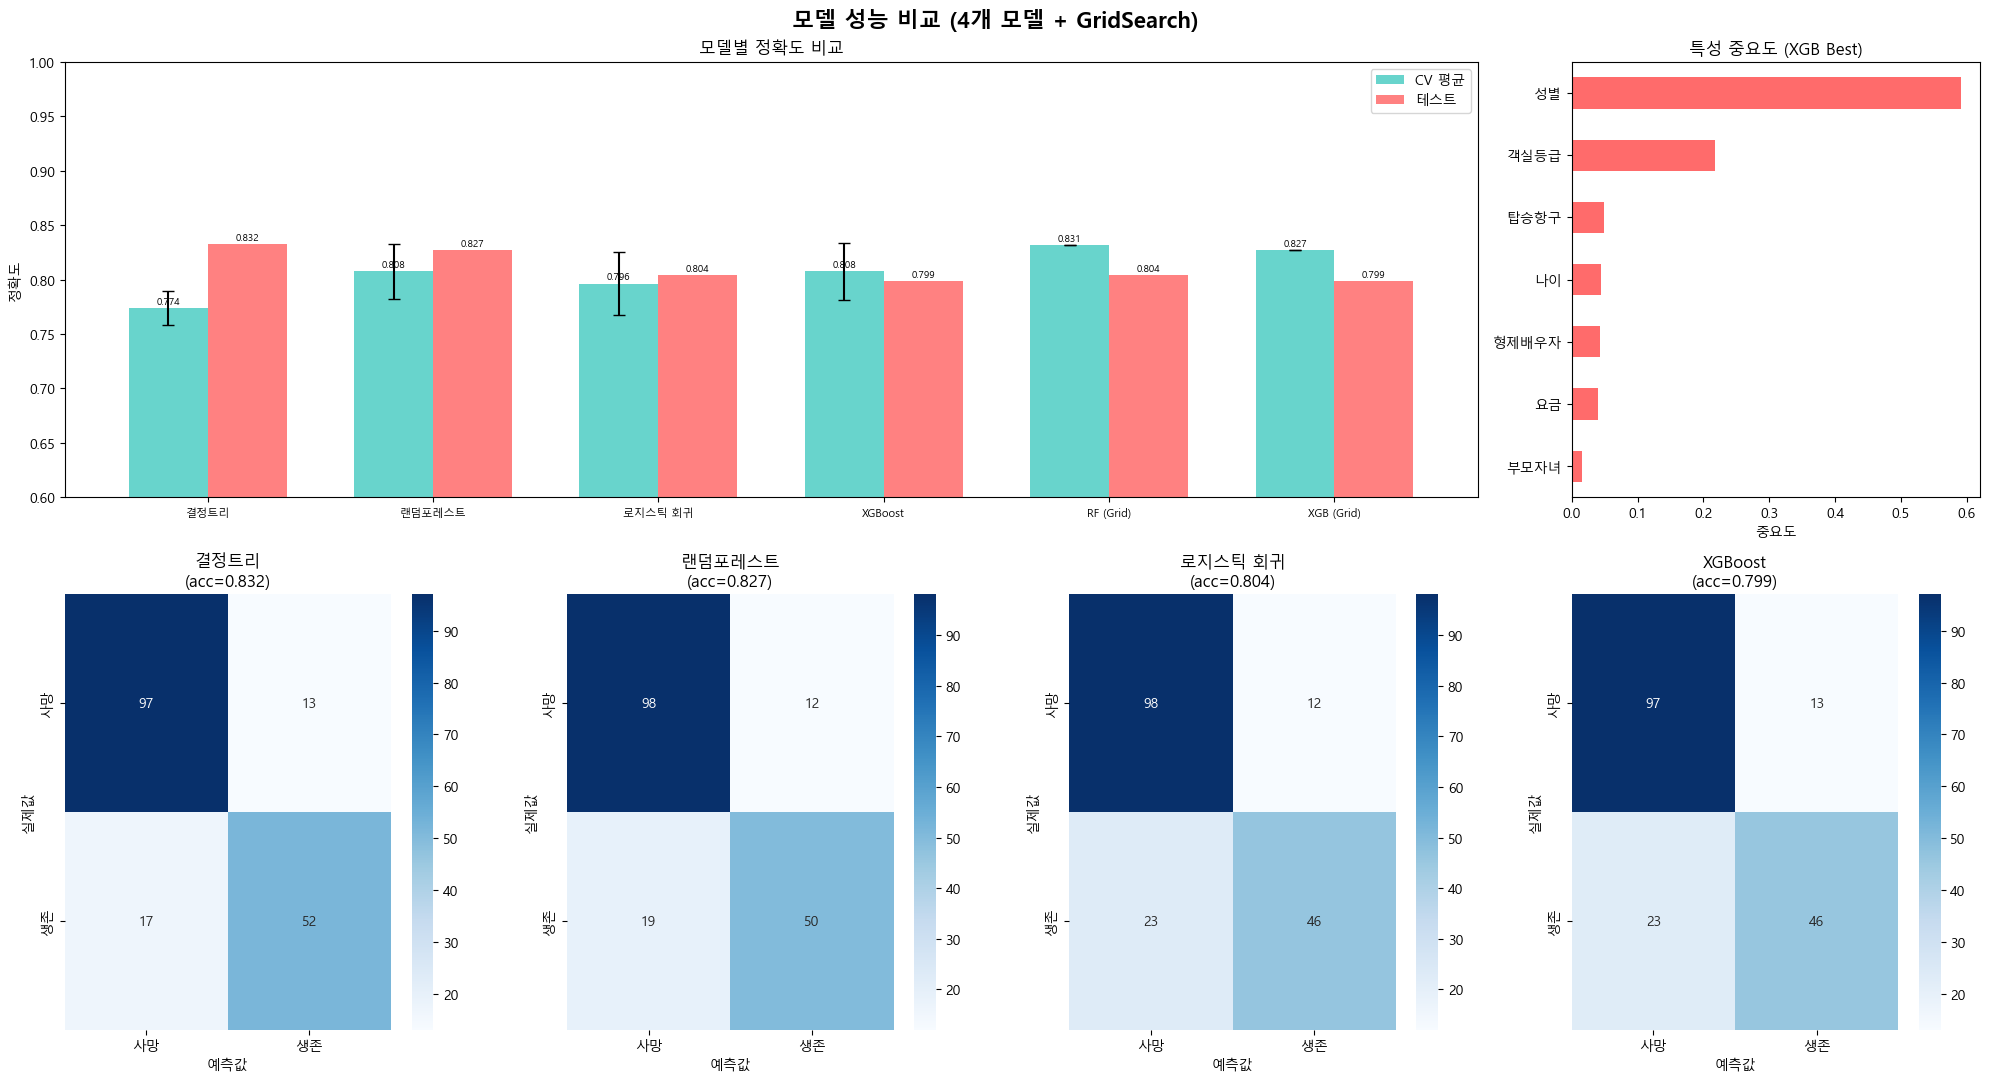

차트 4 저장 완료


In [15]:
# 차트 4: 모델 성능 비교 및 혼동행렬 (XGBoost 포함)
fig = plt.figure(figsize=(20, 11))
fig.suptitle('모델 성능 비교 (4개 모델 + GridSearch)', fontsize=16, fontweight='bold')

# 상단: 모델별 CV/테스트 정확도 비교
ax1 = fig.add_subplot(2, 4, (1, 3))
model_names = list(results.keys()) + ['RF (Grid)', 'XGB (Grid)']
cv_means  = [results[n]['cv_mean']  for n in results] + [rf_grid.best_score_,  xgb_grid.best_score_]
cv_stds   = [results[n]['cv_std']   for n in results] + [0, 0]
test_accs = [results[n]['test_acc'] for n in results] + [rf_best_acc, xgb_best_acc]

x = np.arange(len(model_names))
width = 0.35
bars1 = ax1.bar(x - width/2, cv_means,  width, label='CV 평균', color='#4ECDC4', alpha=0.85)
bars2 = ax1.bar(x + width/2, test_accs, width, label='테스트',  color='#FF6B6B', alpha=0.85)
ax1.errorbar(x - width/2, cv_means, yerr=cv_stds, fmt='none', color='black', capsize=4)
ax1.set_title('모델별 정확도 비교')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=8)
ax1.set_ylabel('정확도')
ax1.set_ylim(0.6, 1.0)
ax1.legend()
for bar in list(bars1) + list(bars2):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# 특성 중요도: XGBoost Best
ax2 = fig.add_subplot(2, 4, 4)
feature_names_kr = ['객실등급', '성별', '나이', '형제배우자', '부모자녀', '요금', '탑승항구']
xgb_imp = pd.Series(best_xgb.feature_importances_, index=feature_names_kr).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=ax2, color='#FF6B6B')
ax2.set_title('특성 중요도 (XGB Best)')
ax2.set_xlabel('중요도')

# 혼동행렬: 4개 모델
for idx, name in enumerate(results.keys()):
    ax = fig.add_subplot(2, 4, 5 + idx)
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['사망', '생존'], yticklabels=['사망', '생존'])
    ax.set_title(f'{name}\n(acc={results[name]["test_acc"]:.3f})')
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + r'\04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('차트 4 저장 완료')

In [16]:
# 전체 결과 요약 및 최고 성능 모델 저장
all_results = {
    **{n: results[n]['test_acc'] for n in results},
    'RF (GridSearch)':  rf_best_acc,
    'XGB (GridSearch)': xgb_best_acc
}

print('=== 최종 결과 요약 (테스트 정확도 기준) ===')
for name, acc in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    marker = ' ★ 최고' if acc == max(all_results.values()) else ''
    print(f'  {name}: {acc:.4f}{marker}')

# 최고 성능 모델 저장
best_name = max(all_results, key=all_results.get)
best_obj  = best_xgb if 'XGB' in best_name else best_rf
model_save_path = OUTPUT_PATH + r'\titanic_model.pkl'
joblib.dump(best_obj, model_save_path)
print(f'\n최고 모델 저장: {best_name} → {model_save_path}')

=== 최종 결과 요약 (테스트 정확도 기준) ===
  결정트리: 0.8324 ★ 최고
  랜덤포레스트: 0.8268
  로지스틱 회귀: 0.8045
  RF (GridSearch): 0.8045
  XGBoost: 0.7989
  XGB (GridSearch): 0.7989

최고 모델 저장: 결정트리 → G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\12_Titanic_ML\output\titanic_model.pkl
